In [4]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification 
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("Libraries Loaded")

Libraries Loaded


In [5]:
import sys
!{sys.executable} -m pip install requests

In [6]:
DATA_FILE = "../data/raw/brca_data.tar.gz"
if os.path.exists(DATA_FILE):
    os.remove(DATA_FILE)
    print("Deleted")
else:
    print("No file found")

Deleted


In [7]:
import requests
import tarfile
DATA_DIR = "../data/raw"
DATA_FILE = os.path.join(DATA_DIR, "brca_data.tar.gz")
URL = "https://datahub.assets.cbioportal.org/brca_tcga_pan_can_atlas_2018.tar.gz"

def download():
    os.makedirs(DATA_DIR, exist_ok=True)
    if not os.path.exists(DATA_FILE):
        response = requests.get(URL, stream=True)
        total = int(response.headers.get('content-length',0))
        downloaded = 0
        with open (DATA_FILE, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                downloaded += len(chunk)
        print('Extracting files......')
        with tarfile.open(DATA_FILE, 'r:gz') as tar:
            tar.extractall(DATA_DIR)
        print("Done")
    else:
        print("Already Downloaded")
download()


Extracting files......
Done


In [8]:
data_path = "../data/raw"
files = os.listdir(data_path)
for f in files:
    print(f)

brca_data.tar.gz
brca_tcga_pan_can_atlas_2018


In [9]:
folder = "../data/raw/brca_tcga_pan_can_atlas_2018"
files = os.listdir(folder)
print("Files inside the folder:")
for f in files:
    print(f)

Files inside the folder:
meta_cna.txt
meta_clinical_sample.txt
meta_phosphoprotein_quantification.txt
meta_sv.txt
data_mrna_seq_v2_rsem_zscores_ref_normal_samples.txt
data_armlevel_cna.txt
meta_methylation_hm27_hm450_merged.txt
meta_rppa.txt
data_cna.txt
data_timeline_treatment.txt
meta_resource_definition.txt
LICENSE
data_clinical_patient.txt
meta_timeline_status.txt
meta_protein_quantification.txt
data_methylation_hm27_hm450_merged.txt
meta_mrna_seq_v2_rsem.txt
data_cna_hg19.seg
data_resource_definition.txt
data_phosphoprotein_quantification.txt
data_timeline_status.txt
data_mrna_seq_v2_rsem_zscores_ref_diploid_samples.txt
meta_resource_patient.txt
data_clinical_sample.txt
data_genetic_ancestry.txt
data_sv.txt
data_rppa_zscores.txt
data_mrna_seq_v2_rsem.txt
README.md
meta_cna_hg19_seg.txt
meta_rppa_zscores.txt
data_log2_cna.txt
meta_log2_cna.txt
meta_gene_panel_matrix.txt
meta_mrna_seq_v2_rsem_zscores_ref_all_samples.txt
case_lists
data_protein_quantification.txt
data_timeline_sample

In [10]:
expr = pd.read_csv(f"{folder}/data_mrna_seq_v2_rsem.txt", sep="\t")
print(expr.shape)
print(expr.head(3))

(20531, 1084)
  Hugo_Symbol  Entrez_Gene_Id  TCGA-3C-AAAU-01  TCGA-3C-AALI-01  \
0         NaN       100130426           0.0000           0.0000   
1         NaN       100133144          16.3644           9.2659   
2    UBE2Q2P2       100134869          12.9316          17.3790   

   TCGA-3C-AALJ-01  TCGA-3C-AALK-01  TCGA-4H-AAAK-01  TCGA-5L-AAT0-01  \
0           0.9066           0.0000           0.0000           0.0000   
1          11.6228          12.0894           6.8468           3.9889   
2           9.2294          11.0799          14.4298          13.6090   

   TCGA-5T-A9QA-01  TCGA-A1-A0SB-01  ...  TCGA-UL-AAZ6-01  TCGA-UU-A93S-01  \
0           0.0000           0.0000  ...           0.0000           0.0000   
1           1.4644          15.3396  ...           0.3992           4.3126   
2           8.9958          14.3935  ...          14.3720          10.8828   

   TCGA-V7-A7HQ-01  TCGA-W8-A86G-01  TCGA-WT-AB41-01  TCGA-WT-AB44-01  \
0           0.0000           0.0000   

In [11]:
#Loading Clinical Data
clinical = pd.read_csv(f"{folder}/data_clinical_sample.txt", sep="\t", skiprows=4)
print(clinical.shape)
print(clinical.columns.tolist())


(1084, 19)
['PATIENT_ID', 'SAMPLE_ID', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TYPE', 'GRADE', 'TISSUE_PROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_SOURCE_SITE_CODE', 'TUMOR_TISSUE_SITE', 'ANEUPLOIDY_SCORE', 'SAMPLE_TYPE', 'MSI_SCORE_MANTIS', 'MSI_SENSOR_SCORE', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS', 'TISSUE_SOURCE_SITE', 'TBL_SCORE']


In [12]:
#Checking the subtypes
print("Cancer subtypes:")
print(clinical['CANCER_TYPE_DETAILED'].value_counts())

Cancer subtypes:
CANCER_TYPE_DETAILED
Breast Invasive Ductal Carcinoma            780
Breast Invasive Lobular Carcinoma           201
Breast Invasive Carcinoma (NOS)              77
Breast Invasive Mixed Mucinous Carcinoma     17
Metaplastic Breast Cancer                     8
Invasive Breast Carcinoma                     1
Name: count, dtype: int64


In [14]:
#Transposing the expression data so that the samples are rows
expr_t = expr.set_index("Hugo_Symbol").drop(columns=["Entrez_Gene_Id"]).T
expr_t.index.name ="SAMPLE_ID"
expr_t = expr_t.reset_index()

#Merging with clincal data
merged = expr_t.merge(clinical[["SAMPLE_ID", "CANCER_TYPE_DETAILED"]], on="SAMPLE_ID")
top4 = ["Breast Invasive Ductal Carcinoma",
        "Breast Invasive Lobular Carcinoma",
        "Breast Invasive Carcinoma (NOS)",
        "Breast Invasive Mixed Mucinous Carcinoma"]
merged = merged[merged["CANCER_TYPE_DETAILED"].isin(top4)]
print(merged.shape)
print(merged["CANCER_TYPE_DETAILED"].value_counts())

(1073, 20533)
CANCER_TYPE_DETAILED
Breast Invasive Ductal Carcinoma            780
Breast Invasive Lobular Carcinoma           201
Breast Invasive Carcinoma (NOS)              75
Breast Invasive Mixed Mucinous Carcinoma     17
Name: count, dtype: int64


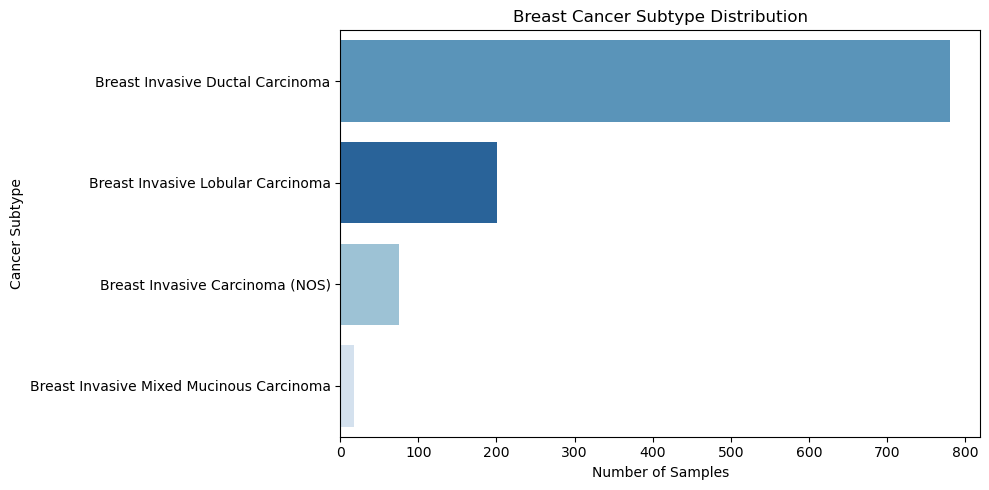

Plot Saved


In [20]:
#Visualizing Distribution"
os.makedirs("../results/figures", exist_ok=True)
plt.figure(figsize=(10,5))
sns.countplot(data = merged, y = "CANCER_TYPE_DETAILED",
              hue = "CANCER_TYPE_DETAILED",
              order = merged["CANCER_TYPE_DETAILED"].value_counts().index,
              palette = "Blues_r",
             legend = False)
plt.title("Breast Cancer Subtype Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Cancer Subtype")
plt.tight_layout()
plt.savefig("../results/figures/Subtype Distribution.png", dpi = 150)
plt.show()
print("Plot Saved")

In [24]:
gene_cols = [col for col in merged.columns if col not in ["SAMPLE_ID", "CANCER_TYPE_DETAILED"]]
variance = merged[gene_cols].var()
top_genes = variance.nlargest(2000).index.tolist()
print(f"Total genes: {len(gene_cols)}")
print(f"Selected genes: {len(top_genes)}")
print(f"Top 5 most variable genes: {top_genes[:5]}")

Total genes: 20531
Selected genes: 2000
Top 5 most variable genes: ['CPB1', 'COL1A1', 'FN1', 'COL1A2', 'COL3A1']


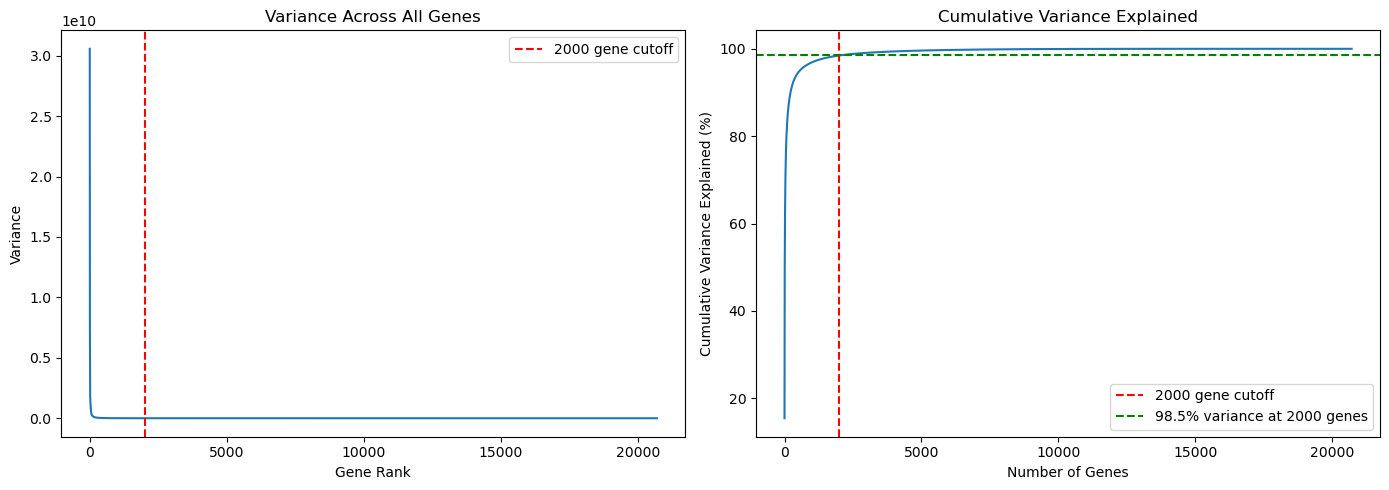


Top 2000 genes capture 98.5% of total variance
Top 1000 genes capture 96.9% of total variance
Top 5000 genes capture 99.6% of total variance


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate variances
variances_sorted = variance.sort_values(ascending=False)

# Plot variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Full variance distribution
axes[0].plot(range(len(variances_sorted)), variances_sorted.values)
axes[0].set_xlabel("Gene Rank")
axes[0].set_ylabel("Variance")
axes[0].set_title("Variance Across All Genes")
axes[0].axvline(x=2000, color='red', linestyle='--', label='2000 gene cutoff')
axes[0].legend()

# Plot 2 - Cumulative variance explained
cumulative = np.cumsum(variances_sorted.values) / np.sum(variances_sorted.values) * 100
axes[1].plot(range(len(cumulative)), cumulative)
axes[1].set_xlabel("Number of Genes")
axes[1].set_ylabel("Cumulative Variance Explained (%)")
axes[1].set_title("Cumulative Variance Explained")
axes[1].axvline(x=2000, color='red', linestyle='--', label='2000 gene cutoff')
axes[1].axhline(y=cumulative[1999], color='green', linestyle='--', 
                label=f'{cumulative[1999]:.1f}% variance at 2000 genes')
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/variance_threshold.png", dpi=150)
plt.show()

print(f"\nTop 2000 genes capture {cumulative[1999]:.1f}% of total variance")
print(f"Top 1000 genes capture {cumulative[999]:.1f}% of total variance")
print(f"Top 5000 genes capture {cumulative[4999]:.1f}% of total variance")

I selected the top 2,000 most variable genes, which capture 98.5% of total variance across all samples. Increasing to 5,000 genes only adds 1.1% additional variance while tripling the feature space, making 2,000 the optimal balance between information retention and computational efficiency."

In [27]:
X = merged[top_genes].values
y = merged["CANCER_TYPE_DETAILED"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"  {label}: {count}")

X shape: (1073, 2004)
y shape: (1073,)

Class distribution:
  Breast Invasive Carcinoma (NOS): 75
  Breast Invasive Ductal Carcinoma: 780
  Breast Invasive Lobular Carcinoma: 201
  Breast Invasive Mixed Mucinous Carcinoma: 17


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
